Ejercicio de regresión logística, KNN y SVM.
### Autora: Laura Johana González Zazueta

Regresion logistica,K vecinos cercanos (KNN) y máquina de Soporte Vectorial (SVM), esto es respecto a la base de datos *Airline Satisfaction passangers* utilizado para el problema de clasificación.

*Creado el 9 de Mayo del 2024, Ensenada, Baja California.*

####  Instrucciones
De la base de datos `Airline-satisfied`:
1. Obtenga las métricas de desempeño para cada una de las técnicas de machine learning, regresión logística, knn y svm.
1. Realice una comparación de las técnicas,  explique las diferencias en los resultados y porqué una técnica fue mejor que otra.

#### NOTA:
La columna A, es la variable dependiente o clases. (Target)

### Base de datos 
Este conjunto de datos contiene una encuesta de satisfacción de los pasajeros de una aerolínea. ¿Qué factores están altamente correlacionados con un pasajero satisfecho (o insatisfecho)? ¿Se puede predecir la satisfacción de los pasajeros?

### Informaci-n de los atributos 

1. `Gender`: (Female, Male)

1. `Customer Type`: (Loyal customer, disloyal customer)

1. `Age`: Edad de los pasajeros 

1. `Type of Travel`: (Personal Travel, Business Travel)

1. `Class`: (Business, Eco, Eco Plus)

1. `Flight distance`: Distancia de vuelo 

1. `Inflight wifi service`: (0:Not Applicable;1-5)

1. `Departure/Arrival time convenient`: Nivel de satisfaccion del tiempo de llegada

1. `Ease of Online booking`: Nivel de satisfaccion en agenda online

1. `Gate location`: Nivel de satisfaccion en la localizacion de la puerta 

1. `Food and drink`: Nivel de satisfaccion de la comida y bebidas

1. `Online boarding`: Nivel de satisfaccion de el abordaje en linea 

1. `Seat comfort`: Nivel de satisfaccion de la comodidad de los asientos 

1. `Inflight entertainment`: Nivel de satisfaccion del entretenimiento dentro del avion 

1. `On-board service`: Nivel de satisfaccion del servicio en el vuelo 

1. `Leg room service`: Nivel de satisfaccion del espacio para piernas 

1. `Baggage handling`: Nivel de satisfaccion del espacio para maletas 

1. `Check-in service`: Nivel de satisfaccion del Check-in service

1. `Inflight service`: Nivel de satisfaccion del inflight service

1. `Cleanliness`: Nivel de satisfaccion de la limpieza 

1. `Departure Delay in Minutes`: Minutos de despegue 

1. `Arrival Delay in Minutes`: Minutos de llegada 

1. `Satisfaction`: Nivel de satisfaccion de la aerolinea (Satisfaction, neutral or dissatisfaction)



In [66]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

In [67]:
#Generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# Base de datos 
data_path = '/home/telematica/Desktop/Algoritmos/datasets/Airline_satisfied - Airline_satisfied.csv'
airline_data = pd.read_csv(data_path)

### Sanity check
Visualización de los primeros cinco registros de la tabla:

In [69]:
 # Verificar los primeros registros del dataset
display(airline_data.head())

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


Visualización de tipo de escalas de medición de los datos en la tabla:


In [70]:
display(airline_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

None

Exploración de información estadística de la tabla:

In [71]:
# Exploración básica de las estadísticas del dataset
display(airline_data.describe())

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Observar los valores faltantes:

In [72]:
display(airline_data.isnull().sum())

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

### Información respecto a las variables categóricas

In [73]:
# Variables categoricas 
categorical_features = ['Customer Type', 'Type of Travel', 'Class', 'Seat comfort', 'Departure/Arrival time convenient','Food and drink',
                       'Gate location','Inflight wifi service','Inflight entertainment','Online support','Ease of Online booking',
                       'On-board service','Leg room service','Baggage handling','Checkin service','Cleanliness','Online boarding']
categorical_summary = []

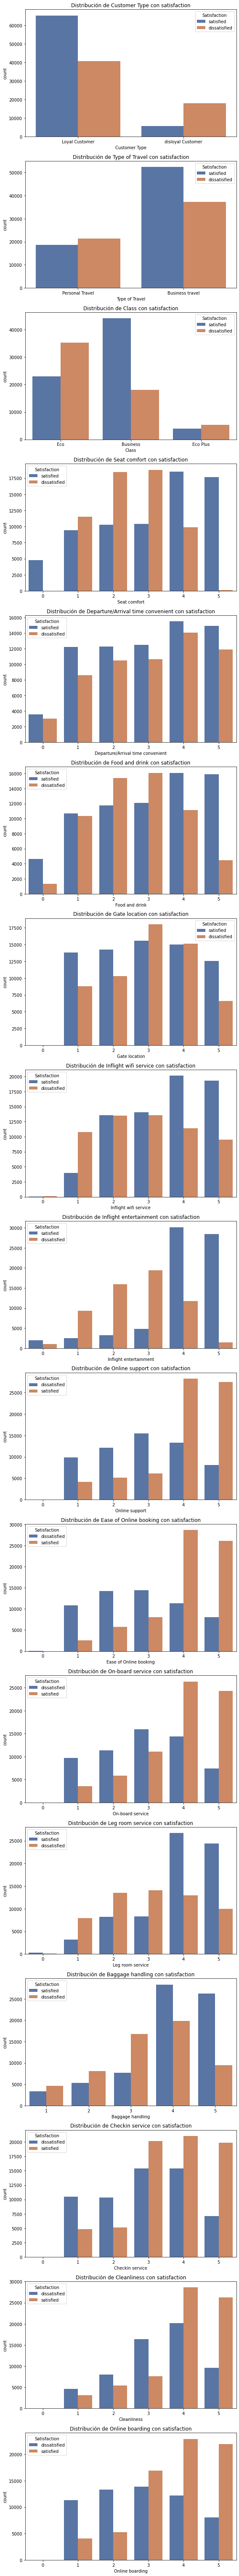

In [74]:
# Análisis Exploratorio de Datos (AED) para Variables Categóricas
fig, axes = plt.subplots(nrows=len(categorical_features), figsize=(8, len(categorical_features) * 5))
if len(categorical_features) == 1:
    axes = [axes]  # Hacer que 'axes' siempre sea una lista
for i, feature in enumerate(categorical_features):
    ax = axes[i] if len(categorical_features) > 1 else axes[0]
    sns.countplot(data=airline_data, x=feature, hue='satisfaction', ax=ax,palette='deep')
    ax.set_title(f'Distribución de {feature} con satisfaction')
    ax.legend(title='Satisfaction')
plt.tight_layout()
plt.show()


In [75]:

# Análisis de calidad de datos para variables categóricas

for feature in categorical_features:
    feature_data = airline_data[feature]
    mode_data = feature_data.mode()
    mode_freq = feature_data.value_counts().iloc[0]
    second_mode_data = feature_data.value_counts().index[1] if len(feature_data.value_counts()) > 1 else None
    second_mode_freq = feature_data.value_counts().iloc[1] if len(feature_data.value_counts()) > 1 else None

    categorical_summary.append({
        'Variable': feature,
        'Valores faltantes': feature_data.isnull().sum(),
        'Cardinalidad': feature_data.nunique(),
        'Moda': mode_data[0],
        'Frecuencia de moda': mode_freq,
        'Segunda moda': second_mode_data,
        'Frecuencia de la segunda moda': second_mode_freq
    })
   
categorical_summary_df = pd.DataFrame(categorical_summary)
display(categorical_summary_df)

,Variable,Valores faltantes,Cardinalidad,Moda,Frecuencia de moda,Segunda moda,Frecuencia de la segunda moda
0,Customer Type,0,2,Loyal Customer,106100,disloyal Customer,23780
1,Type of Travel,0,2,Business travel,89693,Personal Travel,40187
2,Class,0,3,Business,62160,Eco,58309
3,Seat comfort,0,6,3,29183,2,28726
4,Departure/Arrival time convenient,0,6,4,29593,5,26817
5,Food and drink,0,6,3,28150,4,27216
6,Gate location,0,6,3,33546,4,30088
7,Inflight wifi service,0,6,4,31560,5,28830
8,Inflight entertainment,0,6,4,41879,5,29831
9,Online support,0,6,4,41510,5,35563


### Información respecto a las variables numéricas

In [76]:
# Variables numericas
numerical_features = ['Age', 'Flight Distance','Departure Delay in Minutes','Arrival Delay in Minutes']
numerical_summary = []

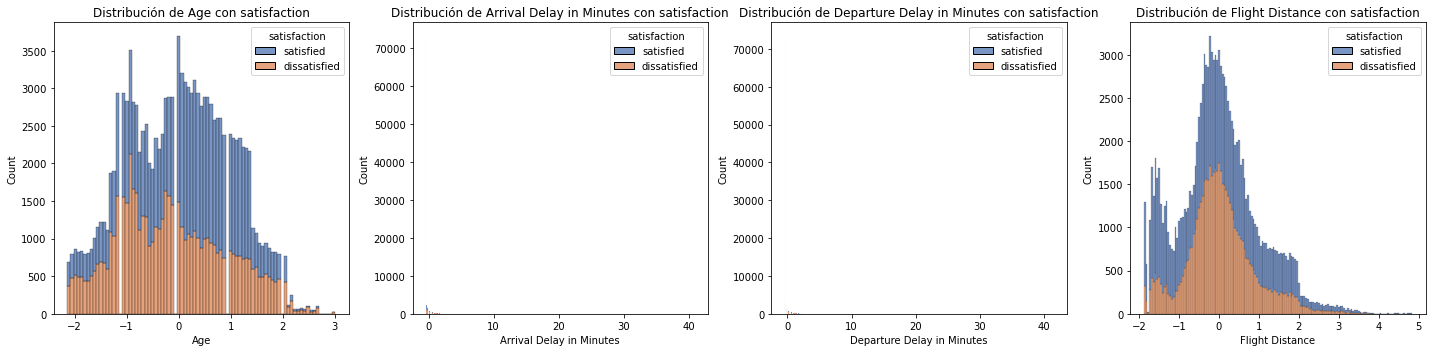

In [99]:
# Análisis Exploratorio de Datos (AED) para Variables Numéricas

# Creamos una figura y ejes para los subplots
fig, axs = plt.subplots(nrows=1, ncols=len(numerical_features), figsize=(20, 5))

# Iteramos sobre las características numéricas y generamos un subplot para cada una
for i, feature in enumerate(numerical_features):
    # Seleccionamos la columna correspondiente en el DataFrame y generamos el gráfico
    sns.histplot(data=airline_data, x=feature, hue='satisfaction', multiple='stack', ax=axs[i], palette='deep')
    axs[i].set_title(f'Distribución de {feature} con satisfaction') # Agregamos el título de la característica

# Ajustamos el espacio entre los subplots
plt.tight_layout()

# Mostramos el gráfico
plt.show()

In [78]:
# Análisis de calidad de datos para variables numéricas

for col in numerical_features:
    col_data = airline_data[col]
    descriptives = col_data.describe()
    
    numerical_summary.append({
        'Variable': col,
        'Count': descriptives['count'],
        'Valores faltantes': col_data.isnull().sum(),
        'Cardinalidad': col_data.nunique(),
        'Mínimo': descriptives['min'],
        '1er cuartil': descriptives['25%'],
        'Media': descriptives['mean'],
        'Mediana': descriptives['50%'],
        '3er cuartil': descriptives['75%'],
        'Máximo': descriptives['max'],
        'Desv. estándar': descriptives['std']
    })

numerical_summary_df = pd.DataFrame(numerical_summary)
display(numerical_summary_df)


,Variable,Count,Valores faltantes,Cardinalidad,Mínimo,1er cuartil,Media,Mediana,3er cuartil,Máximo,Desv. estándar
0,Age,129880.0,0,75,7.0,27.0,39.427957,40.0,51.0,85.0,15.119360
1,Flight Distance,129880.0,0,5398,50.0,1359.0,1981.409055,1925.0,2544.0,6951.0,1027.115606
2,Departure Delay in Minutes,129880.0,0,466,0.0,0.0,14.713713,0.0,12.0,1592.0,38.071126
3,Arrival Delay in Minutes,129487.0,393,472,0.0,0.0,15.091129,0.0,13.0,1584.0,38.465650


###           Preprocesamiento

In [79]:
# Llenar los valores faltantes con la mediana
median_arrival_delay = airline_data['Arrival Delay in Minutes'].median()
airline_data['Arrival Delay in Minutes'].fillna(median_arrival_delay, inplace=True)

# Checar si no hay ningún valor faltante
airline_data.isnull().sum()

satisfaction                         0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

### Entrenamiento del algorítmo

Librerías utilizadas en esta sección:

In [91]:
#Division de datos
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
#Modelos 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
#Resultados
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


División de los datos:

In [ ]:
# Codificación de variables categóricas
encoder = LabelEncoder()
for column in categorical_features:
    airline_data[column] = encoder.fit_transform(airline_data[column])

# Escalado de características numéricas
numerical_features = airline_data.columns.difference(categorical_features + ['satisfaction'])
scaler = StandardScaler()
airline_data[numerical_features] = scaler.fit_transform(airline_data[numerical_features])

# Dividir el conjunto de datos
X = airline_data.drop('satisfaction', axis=1)
y = airline_data['satisfaction']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Regresión logística 

Logistic Regression Accuracy: 0.8258007391438251

Logistic Regression Classification Report:
                precision    recall  f1-score   support

Not Satisfied       0.81      0.81      0.81     11675
    Satisfied       0.84      0.84      0.84     14301

     accuracy                           0.83     25976
    macro avg       0.82      0.82      0.82     25976
 weighted avg       0.83      0.83      0.83     25976



Text(0.5, 24.0, 'Predicciones')

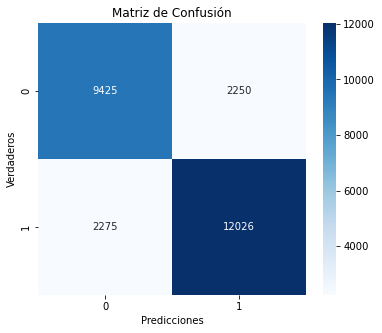

In [93]:
# Modelo
log_reg = LogisticRegression(random_state=42)

# Entrenamiento del modelo
log_reg.fit(X_train, y_train)
# Predicciones
y_pred_log_reg = log_reg.predict(X_test)
# Cálculo de precisión
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
# Reportes de clasificación
log_reg_report = classification_report(y_test, y_pred_log_reg, target_names=['Not Satisfied', 'Satisfied'])
# Mostrar resultados
print("Logistic Regression Accuracy:", log_reg_accuracy)
print("\nLogistic Regression Classification Report:\n", log_reg_report)
conf_matrixRL = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrixRL, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Verdaderos')
plt.xlabel('Predicciones')


### Vecinos cercanos (KNN)

KNN Accuracy: 0.9265860794579612

KNN Classification Report:
                precision    recall  f1-score   support

Not Satisfied       0.91      0.93      0.92     11675
    Satisfied       0.94      0.92      0.93     14301

     accuracy                           0.93     25976
    macro avg       0.93      0.93      0.93     25976
 weighted avg       0.93      0.93      0.93     25976



Text(0.5, 24.0, 'Predicciones')

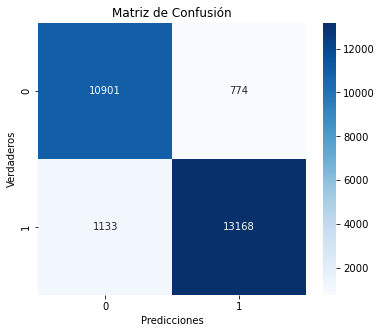

In [96]:
# Modelo 
knn_model = KNeighborsClassifier()

#Entrenamiento del modelo 
knn_model.fit(X_train, y_train)

# Predicciones 
y_pred_knn = knn_model.predict(X_test)

#Calculo de presicion 
knn_accuracy = accuracy_score(y_test, y_pred_knn)

#Reporte de clasificacion 

knn_report = classification_report(y_test, y_pred_knn, target_names=['Not Satisfied', 'Satisfied'])

#Mostrar todos los resultados 
print("KNN Accuracy:", knn_accuracy)
print("\nKNN Classification Report:\n", knn_report)
conf_matrixKNN = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrixKNN, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Verdaderos')
plt.xlabel('Predicciones')

### Máquina de soporte vectorial (SVM)

LinearSVC Accuracy: 0.8266091777024946

LinearSVC Classification Report:
                precision    recall  f1-score   support

Not Satisfied       0.81      0.81      0.81     11675
    Satisfied       0.84      0.84      0.84     14301

     accuracy                           0.83     25976
    macro avg       0.82      0.83      0.82     25976
 weighted avg       0.83      0.83      0.83     25976



Text(0.5, 24.0, 'Predicciones')

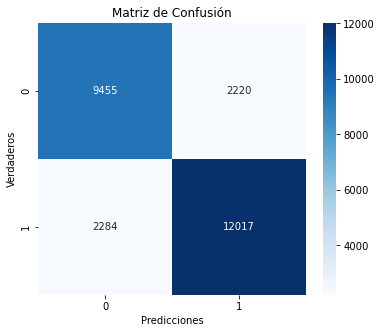

In [97]:
# Modelo 
linear_svc = LinearSVC(random_state=42, max_iter=10000, dual=False)
#Entrenamiento del modelo 
linear_svc.fit(X_train, y_train)
# Predicciones 
y_pred_linear_svc = linear_svc.predict(X_test)
#Calculo de presicion 
linear_svc_accuracy = accuracy_score(y_test, y_pred_linear_svc)
#Reporte de clasificacion 
linear_svc_report = classification_report(y_test, y_pred_linear_svc, target_names=['Not Satisfied', 'Satisfied'])

#Mostrar todos los resultados 
print("LinearSVC Accuracy:", linear_svc_accuracy)
print("\nLinearSVC Classification Report:\n", linear_svc_report)
conf_matrixSVM = confusion_matrix(y_test, y_pred_linear_svc)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrixSVM, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Verdaderos')
plt.xlabel('Predicciones')

### Resultados 

### Regresión Logística
Precisión: 82.58%
##### Reporte de Clasificación:

1. Precision (No Satisfecho): 81%
1. Precision (Satisfecho): 84%
1. Recall (No Satisfecho): 81%
1. Recall (Satisfecho): 84%
1. F1-Score (General): 83%

### Vecinos cercanos (KNN)
Precisión: 92.66%
#### Reporte de Clasificación:

1. Precision (No Satisfecho): 91%
1. Precision (Satisfecho): 94%
1. Recall (No Satisfecho): 93%
1. Recall (Satisfecho): 92%
1. F1-Score (General): 93%

### LinearSVC
Precisión: 82.66%
##### Reporte de Clasificación:

1. Precision (No Satisfecho): 81%
1. Precision (Satisfecho): 84%
1. Recall (No Satisfecho): 81%
1. Recall (Satisfecho): 84%
1. F1-Score (General): 83%

### Discusiones 

Inicialmente se optó por utilizar el modelo LinearSVC ajustado debido a problemas con el entrenamiento del modelo SVC original. Los modelos de Support Vector Machine (SVM), como SVC, pueden ser bastante eficientes en términos de memoria y computación cuando se trabaja con conjuntos de datos de tamaño moderado y cuando el número de características no es excesivamente grande. Sin embargo, con grandes volúmenes de datos, el entrenamiento de un SVC puede volverse muy lento y computacionalmente costoso, Es una buena elección cuando se necesita un modelo eficiente para clasificaciones que se espera sean linealmente separables o cuando se prefiere una simplificación en el manejo de SVMs para grandes datasets.

Al momento de realizar los modelos y obtener los resultados se observa que el modelo KNN supera significativamente a los modelos de Regresión Logística y LinearSVC en términos de precisión y otras métricas de desempeño.La superioridad de KNN en este conjunto de datos sugiere que las clases son localmente agrupables y que las interacciones entre características no son estrictamente lineales. KNN pudo capturar mejor la estructura inherente de los datos debido a su capacidad para adaptarse a la similitud local sin asumir una forma específica para la relación entre características y clases.

En contraste, tanto la Regresión Logística como LinearSVC intentan modelar estas relaciones a través de una función lineal, lo cual puede no ser adecuado si las fronteras de decisión entre clases son complejas o si las características exhiben interacciones no lineales significativas. Esto puede hacer que estos modelos fallen en capturar sutilezas en los datos que un modelo como KNN puede manejar mejor debido a su enfoque flexible y no paramétrico.

### Conslusiones 

KNN mostró un rendimiento superior, con una precisión significativamente más alta que los otros dos modelos. Esto sugiere que KNN es particularmente efectivo para este conjunto de datos debido a su capacidad para adaptarse a las estructuras locales dentro de los datos sin suponer linealidad. KNN podría estar capturando patrones complejos y no lineales que son cruciales para la clasificación en este conjunto específico.Tanto la Regresión Logística como LinearSVC, que son modelos lineales, tuvieron un rendimiento similar y menos efectivo comparado con KNN. Esto indica que las fronteras de decisión entre las clases en tu conjunto de datos pueden no ser lineales, lo cual limita la efectividad de los modelos que dependen de relaciones lineales para clasificación.
